Zaria Taylor Jupyter Notebook - Phase 1 Project

The goal of this notebook is to analyze the role of location in shooting incidents in NYC. 
- Location Description, Borough
- Ages of perpetradors and victims
- Year

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Creation of DataFrame

In [186]:
df = pd.read_csv("../data/processed/clean_data.csv")

df.head(30)


,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN
5,5,209099250,2020-02-05T00:00:00.000,11:51:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,3.0,47.0,59.0,20529.0,51.0,NaN,NaN,NaN
6,6,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,F,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
7,7,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
8,8,208955529,2020-02-03T00:00:00.000,21:12:00,BRONX,47,0.0,True,45-64,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,40.0,30.0,11608.0,29.0,NaN,NaN,NaN
9,9,208899477,2020-02-02T00:00:00.000,15:55:00,BROOKLYN,84,0.0,False,<18,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,38.0,54.0,17619.0,68.0,NaN,NaN,NaN


In [134]:
df.describe()

,Unnamed: 0,incident_key,precinct,jurisdiction_code,latitude,longitude,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer
count,29000.000000,2.900000e+04,29000.000000,28998.000000,28903.000000,28903.000000,28903.000000,28903.000000,28903.000000,28862.000000,28903.000000
mean,499.500000,1.369615e+08,65.207207,0.318263,40.739519,-73.908989,3.280525,29.829845,40.424489,14713.522625,38.665433
std,288.679968,8.149749e+07,27.373641,0.729037,0.087726,0.065619,1.320795,13.940465,16.924575,3784.021785,20.280171
min,0.000000,1.681403e+07,1.000000,0.000000,40.511586,-74.249303,1.000000,1.000000,1.000000,10090.000000,1.000000
25%,249.750000,7.175669e+07,44.000000,0.000000,40.669045,-73.942736,2.000000,17.000000,27.000000,11605.000000,18.000000
50%,499.500000,1.373719e+08,67.000000,0.000000,40.703146,-73.914762,3.000000,31.000000,40.000000,13512.000000,42.000000
75%,749.250000,2.153030e+08,81.000000,0.000000,40.825389,-73.882660,5.000000,42.000000,52.000000,17215.000000,55.000000
max,999.000000,2.994625e+08,123.000000,2.000000,40.910818,-73.702046,5.000000,51.000000,77.000000,24894.000000,71.000000


In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  str    
 3   occur_time                   29000 non-null  str    
 4   boro                         29000 non-null  str    
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  str    
 9   perp_sex                     19704 non-null  str    
 10  perp_race                    19704 non-null  str    
 11  vic_age_group                29000 non-null  str    
 12  vic_sex                      29000 non-null  str    
 13  vic_race                   

In [136]:
df['location_desc'].value_counts()

location_desc
MULTI DWELL - PUBLIC HOUS    5077
MULTI DWELL - APT BUILD      2977
(null)                       2526
PVT HOUSE                     986
GROCERY/BODEGA                759
BAR/NIGHT CLUB                664
COMMERCIAL BLDG               300
RESTAURANT/DINER              206
FAST FOOD                     125
BEAUTY/NAIL SALON             118
HOSPITAL                       84
GAS STATION                    75
SOCIAL CLUB/POLICY LOCATI      74
SMALL MERCHANT                 46
LIQUOR STORE                   42
HOTEL/MOTEL                    37
STORE UNCLASSIFIED             33
DRY CLEANER/LAUNDRY            28
SUPERMARKET                    20
DRUG STORE                     14
JEWELRY STORE                  11
TELECOMM. STORE                11
SHOE STORE                     10
CANDY STORE                    10
CLOTHING BOUTIQUE              10
VARIETY STORE                  10
DEPT STORE                      9
CHAIN STORE                     8
VIDEO STORE                     8


In [137]:
df['boro'].value_counts()

boro
BROOKLYN         11379
BRONX             8630
QUEENS            4318
MANHATTAN         3873
STATEN ISLAND      800
Name: count, dtype: int64

Comparing the shooting incident Location Description to the Borough

In [159]:
perp_location_boro = df.groupby(['location_desc', 'boro']).size().reset_index(name='count')
perp_location_boro.sort_values('count', ascending=False).head(10)

,location_desc,boro,count
92,MULTI DWELL - PUBLIC HOUS,BROOKLYN,2311
91,MULTI DWELL - PUBLIC HOUS,BRONX,1264
87,MULTI DWELL - APT BUILD,BROOKLYN,1180
86,MULTI DWELL - APT BUILD,BRONX,1071
0,(null),BRONX,945
93,MULTI DWELL - PUBLIC HOUS,MANHATTAN,921
1,(null),BROOKLYN,752
94,MULTI DWELL - PUBLIC HOUS,QUEENS,495
2,(null),MANHATTAN,439
101,PVT HOUSE,BROOKLYN,383


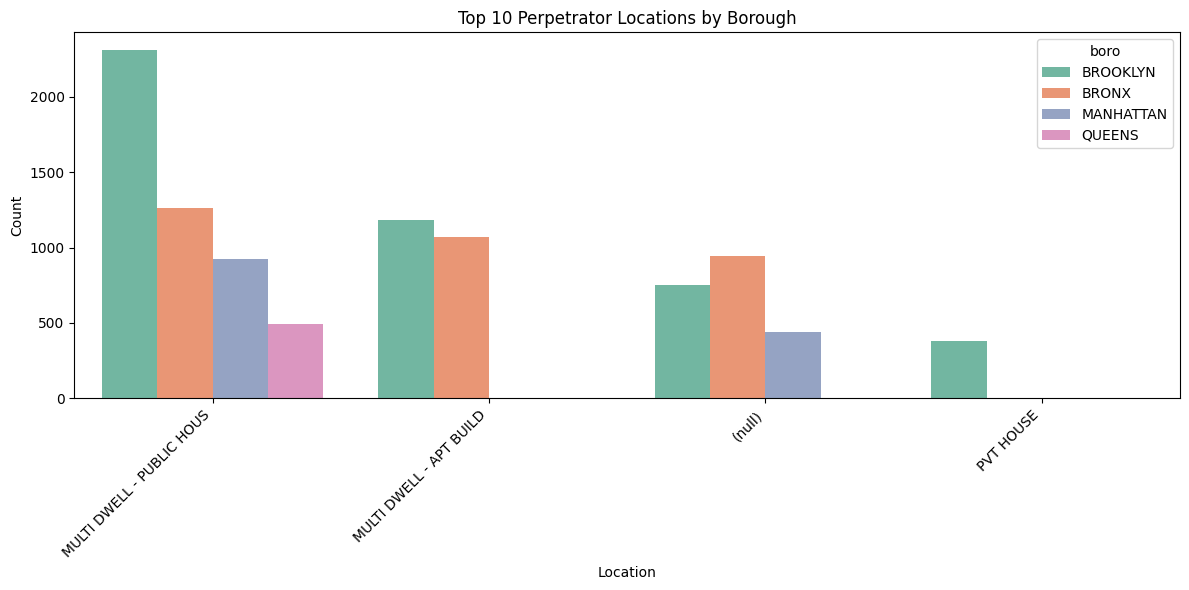

In [170]:
plt.figure(figsize=(12,6))

top10 = perp_location_boro.nlargest(10, 'count')

sns.barplot(
    data=top10,
    x='location_desc',
    y='count',
    hue='boro',
    palette='Set2'
)

plt.title('Top 10 Perpetrator Locations by Borough')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This graph shows the boroughs that had the higehst counts of perpetrators based on specific location descriptions. Overall, Brooklyn is th borough with the highest shooting incident count. The Bronx is the second highest borough. Manhattan is third, then Queens. The data idicates that the 3 most popular location descriptions for perpetrator shootings are in public housing, apartment builidng and private homes amongst all boroughs.

Perpetrator Incidents By Year

In [138]:
df['occur_date'].value_counts()

occur_date
2020-07-05T00:00:00.000    47
2011-09-04T00:00:00.000    31
2020-07-26T00:00:00.000    29
2007-08-11T00:00:00.000    26
2006-09-04T00:00:00.000    25
                           ..
2022-02-24T00:00:00.000     1
2022-02-23T00:00:00.000     1
2022-02-20T00:00:00.000     1
2022-02-15T00:00:00.000     1
2022-02-14T00:00:00.000     1
Name: count, Length: 6270, dtype: int64

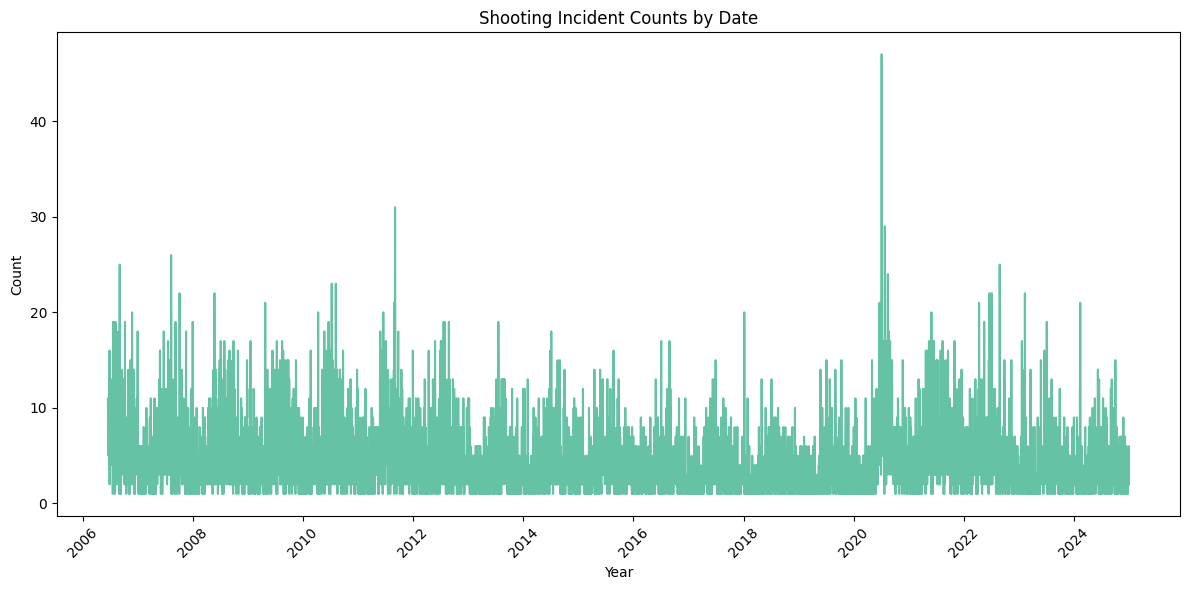

In [185]:
df_counts = (
    df['occur_date']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'occur_date'})
)

df_counts['occur_date'] = pd.to_datetime(df_counts['occur_date'])
df_counts = df_counts.sort_values('occur_date')

plt.figure(figsize=(12,6))
sns.lineplot(data=df_counts, x='occur_date', y='count')

plt.title('Shooting Incident Counts by Date')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This lineplot does not show a strong correlation between the year in which the incidents happen and the number of incidents. There are a few areas where there are peaks in the number of incidents. This is shown around 2011 and 2021.   

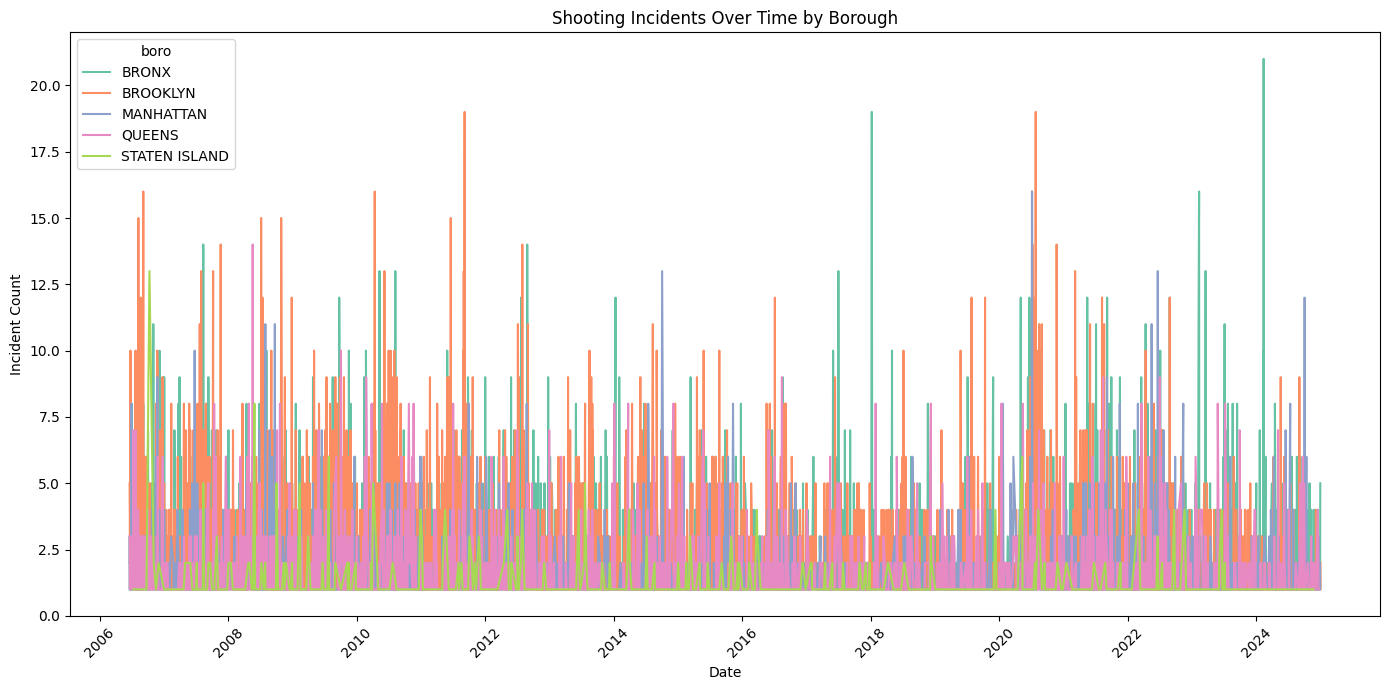

In [180]:
shooting_by_date_boro = (
    df.groupby(['occur_date', 'boro'])
      .size()
      .reset_index(name='count')
)

shooting_by_date_boro['occur_date'] = pd.to_datetime(shooting_by_date_boro['occur_date'])
shooting_by_date_boro = shooting_by_date_boro.sort_values('occur_date')

plt.figure(figsize=(14,7))

sns.lineplot(
    data=shooting_by_date_boro,
    x='occur_date',
    y='count',
    hue='boro',
    palette='Set2'
)

plt.title('Shooting Incidents Over Time by Borough')
plt.xlabel('Date')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This lineplot shows how there is a higher prevelance of shooting incidnets in Brooklyn earlier in the dataset, more specifically between 2006 and 2017 (represented in orange). The there is a shift in the incident count, showing Bronx to have higher prevelance of shooting incidents between 2017 and 2024 (represented in green). There is much to investigate in figuring out what sociopolitical changes in NYC impacted the shift in incident count from one borough to another. 

Perpetrator's Age vs. Victim's Age

In [139]:
df['vic_age_group'].value_counts()

vic_age_group
25-44      13277
18-24      10361
<18         2980
45-64       2081
65+          232
UNKNOWN       68
1022           1
Name: count, dtype: int64

In [140]:
df['perp_age_group'].value_counts()

perp_age_group
18-24      6453
25-44      6169
UNKNOWN    2869
<18        1750
(null)     1628
45-64       763
65+          66
224           1
940           1
1020          1
2021          1
1028          1
Name: count, dtype: int64

perp_age_group
18-24      32.751358
25-44      31.309953
UNKNOWN    14.561234
<18         8.881896
(null)      8.262701
45-64       3.872507
65+         0.334974
224         0.005075
940         0.005075
1020        0.005075
2021        0.005075
1028        0.005075
Name: proportion, dtype: float64


<Axes: title={'center': 'Perpertrator Age Group Distribution'}, xlabel='Age Group', ylabel='Percentage'>

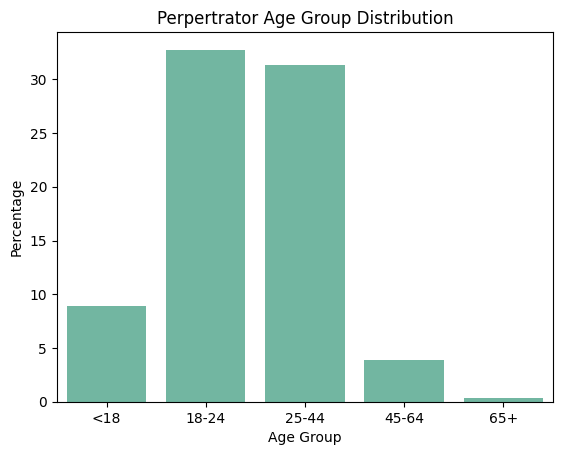

In [141]:
perp_age = df['perp_age_group'].value_counts(normalize = True)* 100
print(perp_age)

age_group = ['<18', '18-24', '25-44', '45-64', '65+',]

plt.title('Perpertrator Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
sns.barplot(x=perp_age.index, y=perp_age.values, order = age_group)

This analysis shows that perpetrators aged 18–24 account for the highest percentage of shooting incidents in NYC. Individuals aged 25–44 make up the second‑largest share of perpetrators involved in these incidents.

vic_age_group
25-44      45.782759
18-24      35.727586
<18        10.275862
45-64       7.175862
65+         0.800000
UNKNOWN     0.234483
1022        0.003448
Name: proportion, dtype: float64


<Axes: title={'center': 'Victim Age Group Distribution'}, xlabel='Age Group', ylabel='Percentage'>

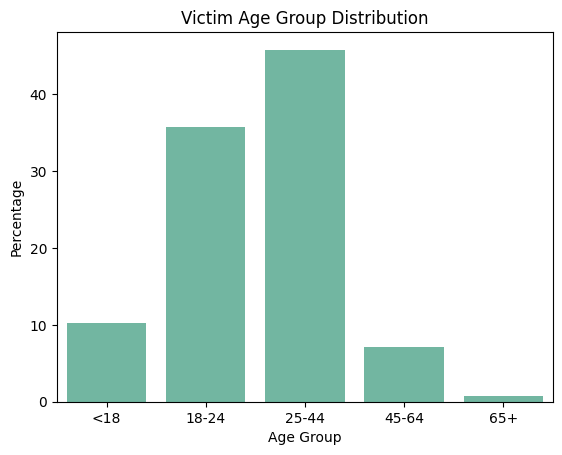

In [142]:
vic_age = df['vic_age_group'].value_counts(normalize = True)* 100
print(vic_age)

age_group = ['<18', '18-24', '25-44', '45-64', '65+',]

plt.title('Victim Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
sns.barplot(x=vic_age.index, y=vic_age.values, order = age_group)

This graph shows that, in NYC shooting incidents, victims aged 25–44 represent the largest share, accounting for 45.78% of all recorded cases.

Compare Perpetrator's Age by Location Description of the Shooting Incident

In [143]:
pivot_table = df.groupby(['location_desc', 'perp_age_group']).size().unstack(fill_value=0)
age_groups = ['<18', '18-24', '25-44', '45-64', '65+']
location_desc = [
    'MULTI DWELL - PUBLIC HOUSE',
    'MULTI DWELL - APT BUILD',
    'PVT HOUSE',
    'GROCERY/BODEGA',
    'BAR/NIGHT CLUB',
    'COMMERCIAL BLDG',
    'RESTAURANT/DINER',
    'FAST FOOD',
    'BEAUTY/NAIL SALON',
    'HOSPITAL',
    'GAS STATION',
    'SOCIAL CLUB/POLICY LOCATION',
    'SMALL MERCHANT',
    'LIQUOR STORE',
    'HOTEL/MOTEL',
    'STORE UNCLASSIFIED',
    'DRY CLEANER/LAUNDRY',
    'SUPERMARKET',
    'DRUG STORE',
    'JEWELRY STORE',
    'TELECOMM. STORE',
    'SHOE STORE',
    'CANDY STORE',
]

pivot_table = pivot_table.reindex(location_desc)

pivot_table = pivot_table[age_groups]
print(pivot_table)


perp_age_group                 <18  18-24  25-44  45-64   65+
location_desc                                                
MULTI DWELL - PUBLIC HOUSE     NaN    NaN    NaN    NaN   NaN
MULTI DWELL - APT BUILD      195.0  721.0  824.0  117.0  14.0
PVT HOUSE                     40.0  194.0  265.0   44.0  20.0
GROCERY/BODEGA                52.0  202.0  198.0   20.0   1.0
BAR/NIGHT CLUB                 0.0  130.0  214.0   21.0   2.0
COMMERCIAL BLDG               10.0   48.0   62.0   10.0   1.0
RESTAURANT/DINER               3.0   45.0   59.0   12.0   0.0
FAST FOOD                      3.0   37.0   25.0    8.0   0.0
BEAUTY/NAIL SALON              1.0   32.0   33.0    1.0   0.0
HOSPITAL                       0.0    5.0   10.0   10.0   0.0
GAS STATION                    3.0   14.0   21.0    0.0   0.0
SOCIAL CLUB/POLICY LOCATION    NaN    NaN    NaN    NaN   NaN
SMALL MERCHANT                 3.0   14.0    9.0    1.0   0.0
LIQUOR STORE                   5.0   16.0    7.0    2.0   0.0
HOTEL/MO

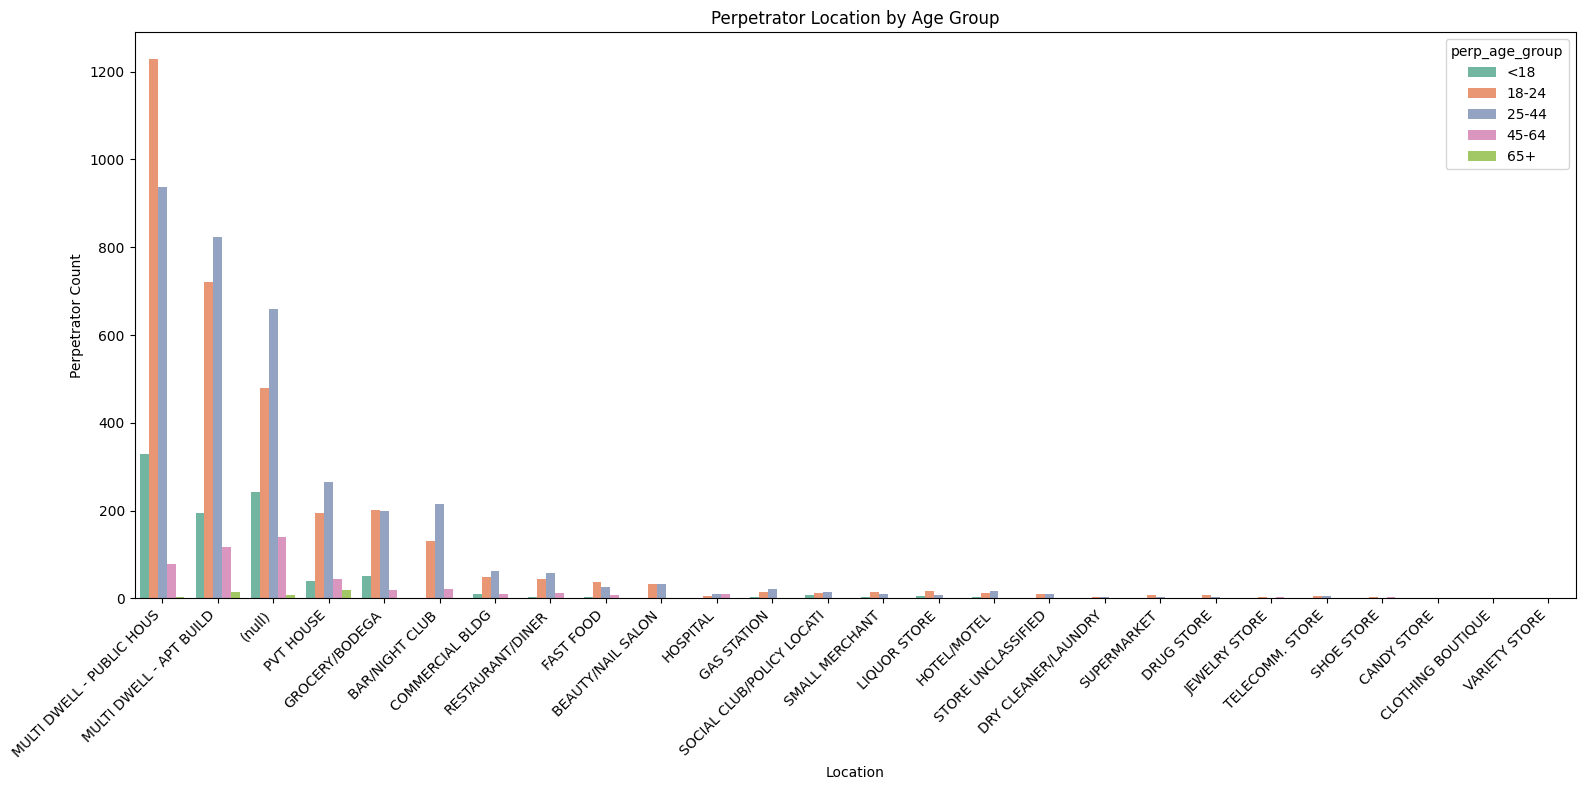

In [158]:
# Filter to meaningful locations
counts = df['location_desc'].value_counts()
valid_locations = counts[counts >= 10].index
df_filtered = df[df['location_desc'].isin(valid_locations)]

# Sort locations by frequency
order = df_filtered['location_desc'].value_counts().index
age_groups = ['<18', '18-24', '25-44', '45-64', '65+']

plt.figure(figsize=(16, 8))
sns.set_palette("Set2")

# use the perp_age_group column (and restrict to known age_groups)
df_plot = df_filtered[df_filtered['perp_age_group'].isin(age_groups)]

sns.countplot(
    data=df_plot,
    x='location_desc',
    hue='perp_age_group',
    order=order,
    hue_order=age_groups
)

plt.title('Perpetrator Location by Age Group')
plt.xlabel('Location')
plt.ylabel('Perpetrator Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The chart provides a broader view of shooting‑incident locations by perpetrator age group. The top three locations with the highest recorded perpetrator counts are public housing, apartment buildings, and private houses. A notably high number of cases list the location as “null,” indicating missing or unclassified location data that may warrant further investigation. Other location types appear far less frequently, underscoring how concentrated these incidents are within multi‑dwelling residential environments.

In [152]:
# Only keep the age groups you care about
age_groups = ['<18', '18-24', '25-44', '45-64', '65+']
df_filtered = df[df['perp_age_group'].isin(age_groups)]

# Count locations within each age group
age_location_counts = (
    df_filtered
    .groupby(['perp_age_group', 'location_desc'])
    .size()
    .reset_index(name='count')
    .rename(columns={'perp_age_group': 'age_group'})
)

# Get the top location for each age group
top_locations = (
    age_location_counts
    .sort_values(['age_group', 'count'], ascending=[True, False])
    .groupby('age_group')
    .head(2)
)

top_locations

,age_group,location_desc,count
20,18-24,MULTI DWELL - PUBLIC HOUS,1228
19,18-24,MULTI DWELL - APT BUILD,721
53,25-44,MULTI DWELL - PUBLIC HOUS,937
52,25-44,MULTI DWELL - APT BUILD,824
67,45-64,(null),141
82,45-64,MULTI DWELL - APT BUILD,117
97,65+,PVT HOUSE,20
95,65+,MULTI DWELL - APT BUILD,14
111,<18,MULTI DWELL - PUBLIC HOUS,329
98,<18,(null),242


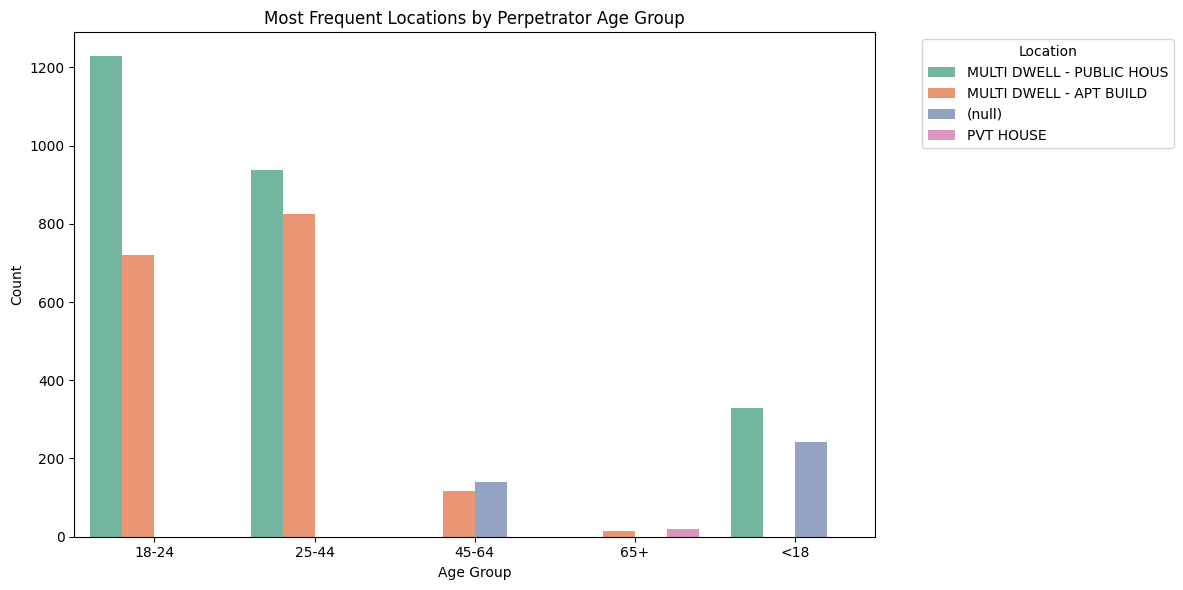

In [154]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_locations, 
    x='age_group', 
    y='count', 
    hue='location_desc',
    palette='Set2'
)

plt.title('Most Frequent Locations by Perpetrator Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This is a more focused vizualization of the the most frequent locations for shooting incidents in NYC based on age of the perpetrator. This focuses on the top 2 locations specified per age group. This also confrims that multi dwellings such as public housing and apartment buldings are the top locations for shooting incidents within the age groups are 18-24 and 25-44 years.